[('西部', 4),
 ('恐怖', 5),
 ('悬疑', 16),
 ('历史', 19),
 ('战争', 20),
 ('纪录', 24),
 ('音乐', 24),
 ('科幻', 27),
 ('家庭', 30),
 ('惊悚', 37),
 ('犯罪', 43),
 ('动作', 44),
 ('喜剧', 47),
 ('爱情', 48),
 ('奇幻', 48),
 ('冒险', 48),
 ('动画', 58),
 ('剧情', 186)]

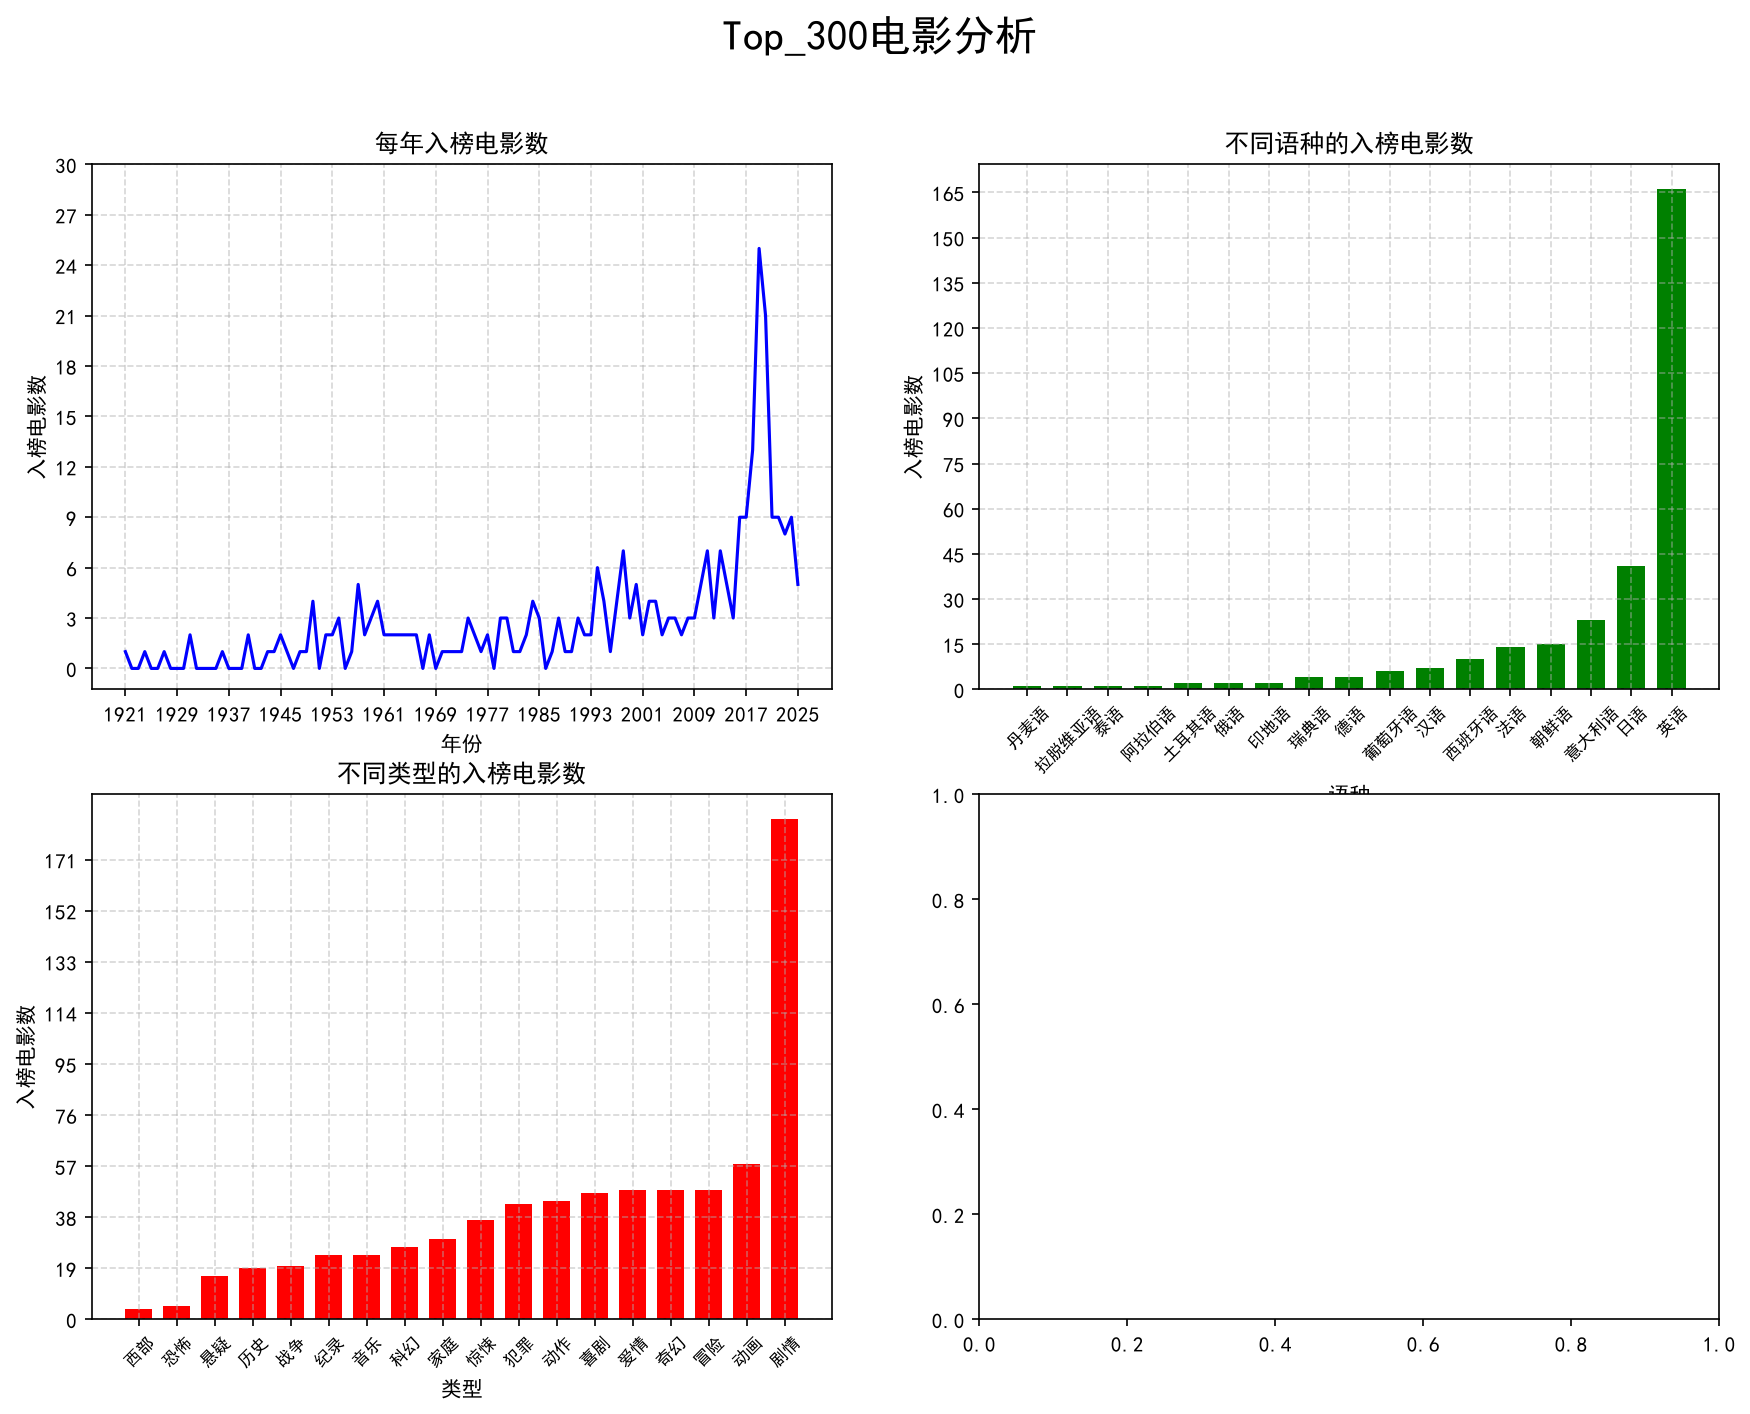

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.axes import Axes #这里甚至还要导入这个..有一点麻烦??

plt.rcParams["font.sans-serif"] = ["SimHei"]
plt.rcParams["axes.unicode_minus"] = False

fig,axes =plt.subplots(2,2,figsize=(14,10),dpi=150)
fig.suptitle("Top_300电影分析",fontsize=20)

axes1: Axes=axes[0,0]
axes2: Axes=axes[0,1]
axes3: Axes=axes[1,0]
axes4: Axes=axes[1,1] #感觉这里定义是不是太麻烦了?

data = pd.read_csv("movies.csv",dtype={"年份":"Int64"})#dtype后面有=,不加dtype的话,年份显示小数类型
#用文本编辑去复制,别直接复制excel,不然会乱
df = data[['电影名', '年份', '上映时间', '类型', '时长', '评分', '语言']]#双[[]]这是大坑

#df.isnull().sum()#查看缺失的总数,看看就行没必要写出来
#会输出这个:
    #电影名     0
    #年份      2
    #上映时间    0
    #类型      0
    #时长      0
    #评分      0
    #语言      0
    #dtype: int64"""


#处理缺失值
df["年份"] = df["年份"].fillna(df["上映时间"].str[0:4])#别写错成str[0,4]了!!!!

#绘图1+数据的处理组装
year_cont=df.groupby("年份")["年份"].count()#为什么会两个年份?
min_year = year_cont.index.min()
max_year = year_cont.index.max()
x = [i for i in range(min_year,max_year+1)]#  x是连续的没什么好说的,但是y比较不一样
#就比如1992年,没有电影进入top300榜单,则x=1992对应的y=0
y =[int(year_cont.get(i,0)) for i in x]

#要加int不然:
 #[np.int64(1),
 #0,
 #0,
 #np.int64(1),
 #0,
 #0,
 #np.int64(1),
 #0,
 #0,
 #...
 #]
#会这样


#绘图1
axes1.plot(x,y,color = 'blue')#blue要加引号
axes1.set_title('每年入榜电影数')
axes1.set_xlabel("年份")
axes1.set_ylabel("入榜电影数")
axes1.set_xticks(x[::8])#莫名其妙加了个S???
y_tick=[i for i in range(0,31,3)]
axes1.set_yticks(y_tick)
axes1.grid(linestyle="--",alpha=0.5)#网格线,透明度0.5



#绘图2   (基本上自己搞出来了哈哈哈)
language = df.groupby("语言")["语言"].count()
language_sorted = language.sort_values()#这种你得重新赋值(有的不用赋值,有的必须赋值怎么区别?)

#其实可以合并:language_sorted = df.groupby("语言")["语言"].count().sort_values()

#这个x,y怎么搞??
x = language_sorted.index
y = language_sorted.values#(加s)
axes2.bar(x,y,color = 'green',width=0.7)#生成柱状图怎么写??--plot换bar
axes2.set_title('不同语种的入榜电影数')
axes2.set_xlabel("语种")
axes2.set_ylabel("入榜电影数")

#axes2.set_xticks()#这种文字类型的x轴标签怎么处理???

axes2.tick_params(axis="x",rotation=45,labelsize=8)  #又是tick,教学代码的知识点 旋转45度,字体大小在8

y_tick=[i for i in range(0,180,15)]
axes2.set_yticks(y_tick)
axes2.grid(linestyle="--",alpha=0.5)#网格线,透明度0.5

#绘图3  (继续)
#统计不同类型的电影数量(柱状图)
#  1.先得知道"类型"有几类,每类有几个,然后根据这个画图即可
#df_type = df.groupby("类型")["类型"].count()   这样是不行的,会输出:
#类型
#冒险,剧情,科幻    1
#冒险,动作,科幻    3
#冒险,喜剧,科幻    1
#冒险,奇幻       2
#冒险,奇幻,动作    3
#          ..
#可以发现,并不是理想中的单个分类,所以要怎么做??
row = {}
Type_df = df["类型"]
for a in Type_df.str.split(","):#为什么加个str??
    for b in a:
        if b in row:
            row[b]+=1
        else:
            row[b]=1
#row2 = pd.DataFrame([row])   pd.DataFrame([])要求是最里面的东西是字典才行,没有[]得是列表才行
#可惜这样的话是横着的表,怎么把表竖起来?然后用x_type = row2.index  y_type = row2.values??
#或者不用 pd.DataFrame这种方式?那么又该怎么弄?主要是我想排序一下,row是字典好像不能直接排序吧?

row2 =sorted(row.items(),key=lambda n :n[1])
#这里直接用items(),把字典分割为元组元素的列表
#像这样:[('剧情', 186), ('犯罪', 43), ('历史', 19)....]
#再用sorted()和lambda匿名函数把列表排序
x_type = [item[0] for item in row2]
y_type = [item[1] for item in row2]
#这里的写法也要注意

#这里就是老生常谈的东西了,复制修改就行
axes3.bar(x_type,y_type,color = 'red',width=0.7)
axes3.set_title('不同类型的入榜电影数')
axes3.set_xlabel("类型")
axes3.set_ylabel("入榜电影数")
axes3.tick_params(axis="x",rotation=45,labelsize=8)
y_tick=[i for i in range(0,190,19)]
axes3.set_yticks(y_tick)
axes3.grid(linestyle="--",alpha=0.5)









